# CREACIÓN DE MODELO DE ARBOL DE DECISIÓN PARA DATASET DE ECOM DATA CHURN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_df = pd.read_csv('/content/ecom_data_transformed.csv')
data_df

,gender,divorced,married,single,login_computer,login_mobile,login_phone,order_fashion,order_grocery,order_laptop,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.000000,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.000000,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0


# CORRELACIONES

In [3]:
corr_matrix = data_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
single,0.180847
order_mobile _phone,0.154387
order_phone,0.113364
device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
payment_cod,0.083933
login_phone,0.078916


<Axes: >

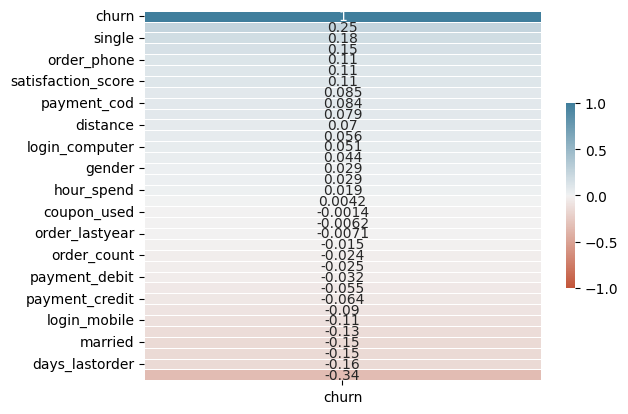

In [4]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = data_df.drop('churn',axis=1)
y = data_df['churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}

clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)
print(f'Mejor combinación de parámetros: {grid_search.best_params_}')

Mejor combinación de parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [10]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.9182948490230906


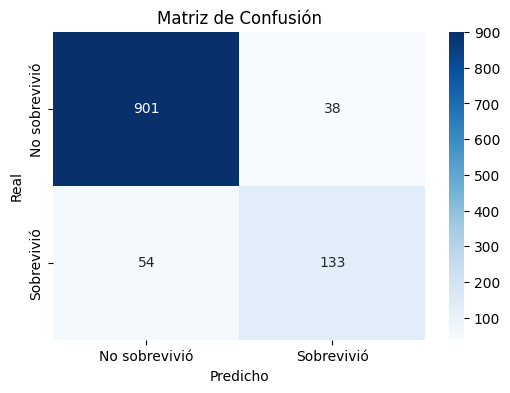

In [11]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()